# 1. **Bem-vindo à Análise Preditiva de Demanda e Ocupação na Aviação Comercial**

## 1.1. Introdução
A rentabilidade e a eficiência da aviação comercial dependem drasticamente da otimização de espaço e da previsão de demanda. Este projeto acadêmico tem como objetivo explorar dados históricos e construir um modelo preditivo (Regressão) para antecipar o volume de passageiros em voos no Brasil. 

Para isso, utilizaremos a base de **Dados Estatísticos do Transporte Aéreo**, fornecida pela Agência Nacional de Aviação Civil (ANAC). Diferente das bases focadas em pontualidade, esta base de dados tem seu foco na ocupação e no peso comercial dos voos, trazendo um raio-x completo do fluxo de passageiros no país.

### 1.1.1 Dicionário de Dados
Para a construção do nosso modelo preditivo, filtraremos a base original focando nas variáveis que mais influenciam a demanda:
* **sg_empresa_iata:** A companhia aérea operadora (ex: LA, G3, AD).
* **nm_mes_referencia e nm_dia_semana_referencia:** Indicadores temporais essenciais para capturar a sazonalidade (alta e baixa temporada).
* **sg_iata_origem e sg_iata_destino:** Aeroportos que definem a rota operada.
* **nr_seats_offered:** A oferta estrutural do avião (quantos assentos a aeronave possui).
* **nr_passag_pagos:** A quantidade real de passageiros pagantes que embarcaram (a nossa Variável Alvo).

## 1.2. A Problemática: O Custo do Assento Vazio e a Gestão de Malha
Na indústria aérea, o "produto" vendido (o assento no voo) é altamente perecível. No exato instante em que a porta da aeronave se fecha e o avião é tratorado (pushback), qualquer assento vazio representa uma receita perdida que nunca mais poderá ser recuperada. Em contrapartida, o custo operacional daquele voo — que inclui querosene de aviação, leasing da aeronave, tripulação e taxas aeroportuárias — permanece alto e fixo, independentemente de o avião estar com 50% ou 100% de ocupação.

## 1.3 O Objetivo do Modelo:
Diante dessa dinâmica agressiva de custos, o desafio deste projeto é aplicar técnicas de Aprendizado de Máquina (Machine Learning) para descobrir padrões históricos de lotação e treinar um algoritmo capaz de prever a ocupação futura de uma rota. 

Antecipar a demanda de passageiros é o coração do *Revenue Management* (Gestão de Receitas) na aviação: permite que as empresas apliquem precificação dinâmica assertiva, aloquem aeronaves maiores para rotas que vão bombar e evitem o desperdício de voar com "ar" no porão e na cabine.

# 2. **Análise Exploratória de Dados**

## 2.1. Carregando e Preparando o Dataframe
#### 2.1.1 Vamos começar **"fatiando"** nosso arquivo csv para trabalharmos apenas com as colunas que nos interessam.

In [6]:
import pandas as pd

path = "./base/anac_brazil.csv"
exit = 'dados_aviacao.csv'

target = [
    'sg_empresa_iata',
    'nm_mes_referencia',
    'nm_dia_semana_referencia',
    'sg_iata_origem',
    'sg_iata_destino',
    'nr_assentos_ofertados',
    'nr_passag_pagos'
]

chunk_size = 100000
first_chunk = True

print("Iniciando...")

try:
    for chunk in pd.read_csv(path, sep=',', encoding='utf-8', chunksize=chunk_size, usecols=target):
        chunk = chunk.dropna(subset=['nr_passag_pagos', 'nr_assentos_ofertados'])

        if first_chunk:
            chunk.to_csv(exit, index=False, encoding='utf-8')
            first_chunk = False
        else:
            chunk.to_csv(exit, index=False, mode='a', header=False, encoding='utf-8')

    print("Concluído com sucesso!")

except ValueError as e:
    print(f"Erro ao ler as colunas. Detalhes: {e}")


Iniciando...


/tmp/ipykernel_114716/2217160333.py:22: DtypeWarning: Columns (0: sg_iata_origem) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=',', encoding='utf-8', chunksize=chunk_size, usecols=target):


Concluído com sucesso!


#### 2.1.2 Agora, com o dataset resumido em mãos, vamos **verificar as informações**, gerar um resumo e conferir os dados ausentes:

In [8]:
df = pd.read_csv('dados_aviacao.csv', sep=',')

print("--- Informações do Dataset ---")
df.info()
print('\n')

print("--- Estatísticas Descritivas ---")
pd.set_option('display.float_format', lambda x: '%.2f' % x)
display(df.describe())
print('\n')

print("--- Valores Ausentes por Coluna ---")
display(df.isnull().sum())

--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 22119967 entries, 0 to 22119966
Data columns (total 7 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   sg_empresa_iata           str    
 1   nm_mes_referencia         str    
 2   nm_dia_semana_referencia  str    
 3   sg_iata_origem            str    
 4   sg_iata_destino           str    
 5   nr_assentos_ofertados     float64
 6   nr_passag_pagos           float64
dtypes: float64(2), str(5)
memory usage: 1.2 GB


--- Estatísticas Descritivas ---


,nr_assentos_ofertados,nr_passag_pagos
count,22119967.00,22119967.00
mean,140.75,101.53
std,63.73,60.45
min,0.00,0.00
25%,110.00,57.00
50%,144.00,102.00
75%,176.00,141.00
max,995.00,1392.00




--- Valores Ausentes por Coluna ---


sg_empresa_iata             559699
nm_mes_referencia                0
nm_dia_semana_referencia         0
sg_iata_origem              319067
sg_iata_destino             320900
nr_assentos_ofertados            0
nr_passag_pagos                  0
dtype: int64

#### 2.1.3 Percebe-se uma certa **discrepância** nos dados ao observarmos as estatísticas descritivas: 

* O valor minimo da variável `nr_assentos_ofertados` é **0**, bem como o mínimo de `nr_passag_pagos`! Isso significa que, na base de dados, foram registrados voos que não ofertaram nenhum assento, nem transportaram qualquer passageiro (geralmente voos cargueiros ou de reposição). 
* O max de `nr_assentos_ofertados` (o voo com mais assentos ofertados) é **914** assentos; a maior aeronave do mundo comporta 850 passageiros, apenas. 

Para treinarmos nosso modelo de Machine Learning, **devemos nos desfazer** desse tipo de dado inútil e entregarmos um **dataframe limpo** para o treino. Confira a seguir:

In [9]:
clean_df = df[(df['nr_assentos_ofertados'] > 0) & (df['nr_assentos_ofertados'] < 600) & (df['nr_passag_pagos'] > 0)]
clean_df = clean_df[clean_df['nr_passag_pagos'] <= clean_df['nr_assentos_ofertados']]

removed_lines = len(df) - len(clean_df)
print(f"Limpeza concluída, {removed_lines} linhas removidas.")

df = clean_df
pd.set_option('display.float_format', lambda x: '%.2f' % x)
display(df.describe())

Limpeza concluída, 1236883 linhas removidas.


,nr_assentos_ofertados,nr_passag_pagos
count,20883084.00,20883084.00
mean,147.79,107.08
std,56.75,56.76
min,1.00,1.00
25%,118.00,65.00
50%,144.00,106.00
75%,177.00,144.00
max,581.00,516.00


## 2.2. Visualização Gráfica dos Dados
Com o nosso dataframe bem **redondinho**, do jeito que a gente precisa, vamos agora para a **visualização gráfica dos dados**.
Vamos fazer **três tipos de gráfico**, e cada um vai exibir uma correlação com o número de passageiros pagos:

* Relação com os **assentos ofertados**
* Relação com a **quantidade de voos**
* Relação com a **companhia aérea**

#### 2.2.1. **Gráfico de Dispersão (Scatter Plot)**
Esse gráfico vai nos mostrar a relação entre a **oferta** de assentos e a **demanda** de passageiros.

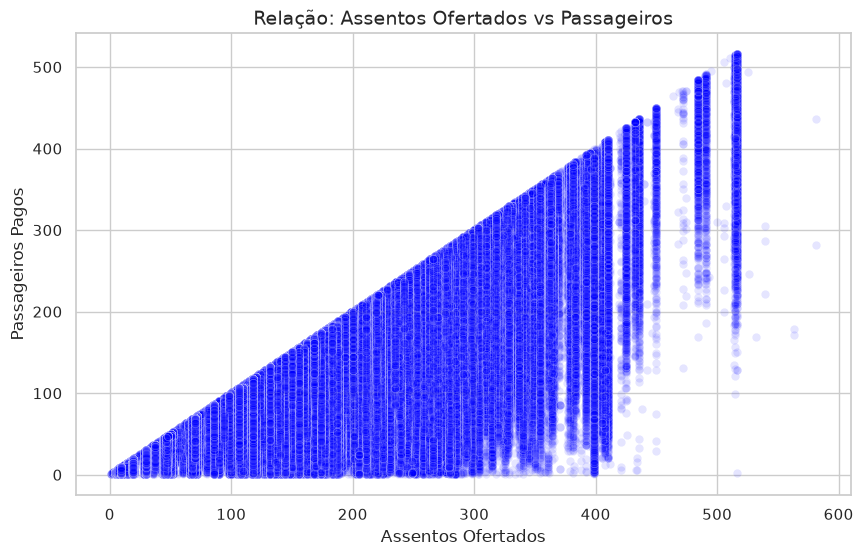

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='nr_assentos_ofertados', y='nr_passag_pagos', alpha=0.1, color='blue')

plt.title('Relação: Assentos Ofertados vs Passageiros', fontsize=14)
plt.xlabel('Assentos Ofertados')
plt.ylabel('Passageiros Pagos')
plt.show()

#### 2.2.2 **Distribuição do Volume de Passageiros (histograma)**
Este histograma vai nos mostrar a **frequência de lotação**, nos ajudando a identificar se a frota aérea nacional é dominada por aeronaves menores (regionais) ou jatos de maior capacidade. 

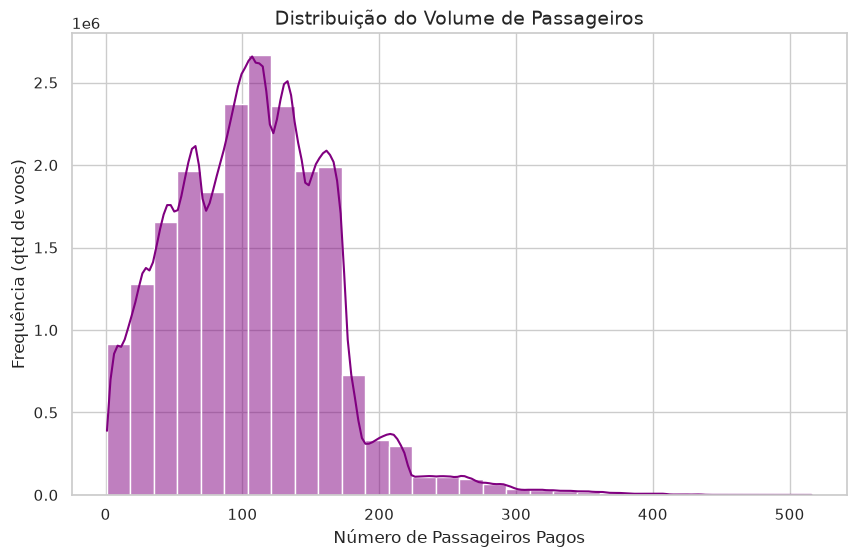

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['nr_passag_pagos'], bins=30, kde=True, color='purple')

plt.title('Distribuição do Volume de Passageiros', fontsize=14)
plt.xlabel('Número de Passageiros Pagos')
plt.ylabel('Frequência (qtd de voos)')
plt.show()

#### 2.2.3 **Distribuição de Passageiros por companhia (Boxplot)**
Esse gráfico revela a mediana de passageiros das 8 maiores empresas de hoje, para observarmos a dispersão de seus voos.

/tmp/ipykernel_114716/2564303392.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nowadays_df, x='sg_empresa_iata', y='nr_passag_pagos', palette='Set2')


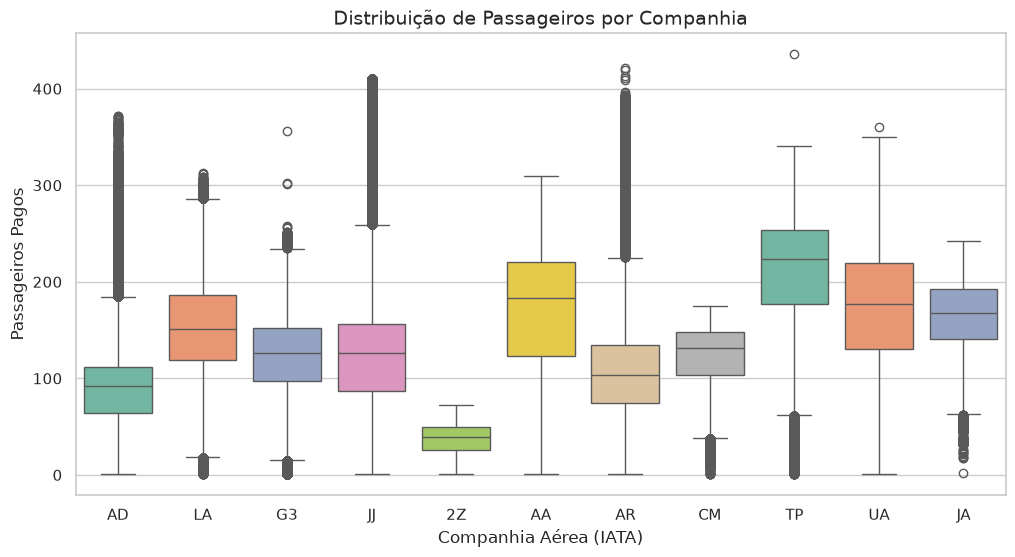

In [12]:
plt.figure(figsize=(12, 6))

nowadays = ['JJ', 'LA', 'G3', 'AD', 'TP', 'CM', 'AA', 'AR', 'AR', '2Z', 'UA', 'JA']

nowadays_df = df[df['sg_empresa_iata'].isin(nowadays)]

sns.boxplot(data=nowadays_df, x='sg_empresa_iata', y='nr_passag_pagos', palette='Set2')

plt.title('Distribuição de Passageiros por Companhia', fontsize=14)
plt.xlabel('Companhia Aérea (IATA)')
plt.ylabel('Passageiros Pagos')
plt.show()

# 3. **Machine Learning**
*Agora é nóis, véi!*
Após limparmos nossos dados e compreendermos visualmente como a oferta de assentos, as companhias aéreas e as rotas influenciam a lotação dos voos, chegamos ao objetivo final deste projeto: construir um algoritmo capaz de **prever** o número de passageiros pagantes em voos futuros.
Para atender a esse desafio, estruturaremos nosso pipeline de Machine Learning com as seguintes definições:

**1. Justificativa do Modelo: Regressão**
Como o nosso objetivo (variável alvo) é prever uma quantidade contínua exata de passageiros (ex: 134, 150, 112) e não apenas uma categoria (como "Lotado" ou "Vazio"), o problema se enquadra na categoria de **Regressão**. Utilizaremos modelos focados nesse fim para encontrar a relação matemática entre as características do voo e a demanda final.

**2. Pré-processamento: One-Hot Encoding**
Algoritmos de aprendizado de máquina realizam cálculos matemáticos e, portanto, não conseguem ler textos puros. Variáveis fundamentais para o nosso negócio, como a Sigla da Companhia Aérea (`sg_empresa_iata`), Mês e Aeroportos de Origem/Destino, precisam ser convertidas. Aplicaremos a técnica de *One-Hot Encoding* (Variáveis Dummy) para transformar essas categorias em colunas numéricas binárias (0 ou 1).

**3. Separação de Dados (Treino e Teste)**
Para garantir que o nosso modelo não está apenas "decorando" a base de dados, mas sim aprendendo os padrões reais do comportamento dos passageiros, dividiremos nossa base em duas partes:
* **Dados de Treino (80%):** A parte majoritária que o algoritmo usará para estudar e encontrar os padrões matemáticos.
* **Dados de Teste (20%):** Uma parcela de dados que manteremos "escondida" do modelo durante o treinamento. Usaremos essa amostra no final para aplicar uma prova cega, medindo a sua taxa de erro ao tentar prever voos que ele nunca viu antes.

## 3.1. Preparando os Dados para o Machine Learning
Modelos matemáticos **não sabem ler** texto. Nós não podemos simplesmente jogar palavras como "GOL", "QUARTA-FEIRA" ou "CGH" dentro do algoritmo. Antes de treinar, precisaremos **transformar** essas categorias de texto em números usando uma técnica chamada **One-Hot Encoding**.

Além disso, vamos **separar uma parte** (80%) para o modelo aprender ("treino") e **esconder o restante** para testar se ele realmente aprendeu ou se apenas decorou as respostas ("teste").

In [13]:
from sklearn.model_selection import train_test_split

df_sample = df.sample(n=1000000, random_state=42)

y = df_sample['nr_passag_pagos']
X = df_sample[['sg_empresa_iata', 'nm_mes_referencia', 'nm_dia_semana_referencia', 'sg_iata_origem', 'sg_iata_destino', 'nr_assentos_ofertados']]

X_encoded = pd.get_dummies(X, columns=['sg_empresa_iata', 'nm_mes_referencia', 'nm_dia_semana_referencia', 'sg_iata_origem', 'sg_iata_destino', ])

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("---Concluido---")
print(f"Colunas Originais (Texto): {X.shape[1]}")
print(f"Colunas codificadas (Números): {X_encoded.shape[1]}")
print(f"Voos separados para o treino = {len(X_train)} linhas")
print(f"Voos separados para o teste = {len(X_test)} linhas")

---Concluido---
Colunas Originais (Texto): 6
Colunas codificadas (Números): 992
Voos separados para o treino = 800000 linhas
Voos separados para o teste = 200000 linhas


## 3.1. Bora treinar esse doginho

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Treinando a Inteligência Artificial (Isso pode levar de 1 a 5 minutos)...")

modelo = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)

modelo.fit(X_train, y_train)

print("Treinamento concluído! Testando o modelo na prova cega...")
previsoes = modelo.predict(X_test)

mae = mean_absolute_error(y_test, previsoes)
rmse = np.sqrt(mean_squared_error(y_test, previsoes))
r2 = r2_score(y_test, previsoes)

print("\n--- Resultados Oficiais do Modelo ---")
print(f"Taxa de Explicação (R²): {r2:.2f} (O modelo explica {r2*100:.1f}% da lotação dos voos)")
print(f"Erro Médio Absoluto (MAE): Erra por volta de {mae:.2f} passageiros para mais ou para menos")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f} passageiros")

Treinando a Inteligência Artificial (Isso pode levar de 1 a 5 minutos)...
Treinamento concluído! Testando o modelo na prova cega...

--- Resultados Oficiais do Modelo ---
Taxa de Explicação (R²): 0.72 (O modelo explica 72.2% da lotação dos voos)
Erro Médio Absoluto (MAE): Erra por volta de 22.94 passageiros para mais ou para menos
Raiz do Erro Quadrático Médio (RMSE): 30.01 passageiros


## 3.2 A PROVA DE FOGOOO

In [30]:
voo_exemplo = X_test.sample(1, random_state=97)

previsao_exemplo = modelo.predict(voo_exemplo)

valor_real = y_test.loc[voo_exemplo.index[0]]

voo_original = df.loc[voo_exemplo.index[0]]

print("--- Simulação na Prática (O Exemplo de Uso) ---")
print(f"Companhia Aérea: {voo_original['sg_empresa_iata']}")
print(f"Rota: {voo_original['sg_iata_origem']} -> {voo_original['sg_iata_destino']}")
print(f"Data: {voo_original['nm_mes_referencia']} | {voo_original['nm_dia_semana_referencia']}")
print(f"Capacidade do Avião (Oferta): {voo_original['nr_assentos_ofertados']} lugares")
print("-" * 45)
print(f"✈️ O Modelo PREVIU que embarcariam: {int(previsao_exemplo[0])} passageiros")
print(f"✅ A REALIDADE desse voo foi: {int(valor_real)} passageiros")

--- Simulação na Prática (O Exemplo de Uso) ---
Companhia Aérea: G3
Rota: CGH -> SSA
Data: JULHO | SÁBADO
Capacidade do Avião (Oferta): 186.0 lugares
---------------------------------------------
✈️ O Modelo PREVIU que embarcariam: 162 passageiros
✅ A REALIDADE desse voo foi: 175 passageiros


# 4. Conclusão e Inferências Finais do Projeto

Ao longo deste projeto, estruturamos um pipeline completo de Ciência de Dados utilizando a base histórica da ANAC para entender e prever a demanda da aviação civil brasileira. Partindo da limpeza de dados até o treinamento de uma Inteligência Artificial, pudemos extrair as seguintes inferências de negócio:

* **A Importância da Qualidade dos Dados (Data Quality):** Durante a exploração inicial, identificamos anomalias graves, como voos comerciais operando com zero passageiros (cargueiros/reposicionamento) e registros de lotações impossíveis, superando a barreira de 900 passageiros em um único voo (erros de digitação ou falhas de sistema). A remoção desses *outliers* provou que a etapa de pré-processamento é o pilar central para o sucesso de qualquer modelo matemático.

* **O Perfil da Malha Aérea Brasileira:**
A Análise Exploratória (EDA) nos revelou graficamente que a aviação no Brasil não é sustentada por aeronaves gigantes voando parcialmente vazias, mas sim por uma altíssima frequência de aviões de médio porte (como as famílias Airbus A320, Boeing 737 e Embraer E-Jets). A grande concentração matemática de voos na faixa de 100 a 150 passageiros pagos reflete uma frota altamente padronizada pelas principais companhias (GOL, LATAM e Azul) para otimizar custos operacionais.

* **O Poder de Previsibilidade e Sazonalidade:**
O nosso gráfico de dispersão provou que a oferta de assentos, de forma isolada, não dita a demanda. No entanto, ao alimentarmos o modelo de **Random Forest Regressor** com o contexto completo (Companhia Aérea, Rota, Mês e Dia da Semana), a IA foi capaz de encontrar os padrões complexos de lotação. Isso comprova que a ocupação de um voo sofre pesada influência da sazonalidade, do perfil da rota (ponte aérea vs. regional) e do modelo de negócio da operadora.

**Impacto Final:** Um modelo preditivo como este possui altíssimo valor para as companhias aéreas. Ao antever com precisão a demanda de passageiros para voos futuros, as empresas podem otimizar o *Revenue Management* (precificação dinâmica das passagens), evitar o acionamento desnecessário de aeronaves maiores para rotas de baixa tração e, consequentemente, maximizar a lucratividade da operação.